In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("all versions imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.version}")

all versions imported successfully!
pandas version: 2.2.2
sqlite3 version: 2.6.0


In [ ]:
pip install my_library

In [ ]:
conn=sqlite3.connect('student.db')

In [5]:
student_df = pd.read_csv('student_performance.csv')
student_df.to_sql('students', conn, if_exists='replace', index=False)
print("Students table created and populated from student_performance.csv")

Students table created and populated from student_performance.csv


In [6]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('student.db')

query1 = """
SELECT
    department,
    ROUND(AVG(math_score), 1) AS avg_math_score
FROM students
GROUP BY department
ORDER BY avg_math_score DESC
"""

avg_math_df = pd.read_sql_query(query1, conn)

print("\nAverage Math Score by Department")
print(avg_math_df)


Average Math Score by Department
         department  avg_math_score
0  Computer Science            85.6
1        Mechanical            71.0
2       Electronics            71.0
3             Civil            63.4


In [7]:
query2 = """
SELECT
    department,
    COUNT(*) AS student_count
FROM students
GROUP BY department
"""

student_count_df = pd.read_sql_query(query2, conn)

print("\nStudent Count by Department")
print(student_count_df)


Student Count by Department
         department  student_count
0             Civil              5
1  Computer Science             13
2       Electronics              6
3        Mechanical              6


In [8]:
query3 = """
SELECT
    name,
    (
        math_score +
        science_score +
        english_score +
        programming_score
    ) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

top_students_df = pd.read_sql_query(query3, conn)

print("\nTop 8 Students")
print(top_students_df)


Top 8 Students
             name  total_score
0      Ananya Das          371
1     Tanvi Mehta          367
2  Akanksha Yadav          365
3      Arjun Nair          356
4     Divya Singh          356
5  Swati Kulkarni          354
6       Amit Bose          336
7      Suresh Rao          334


In [9]:
query4 = """
SELECT
    gender,
    ROUND(AVG(attendance_percentage), 1) AS avg_attendance
FROM students
GROUP BY gender
"""

attendance_df = pd.read_sql_query(query4, conn)

print("\nAverage Attendance by Gender")
print(attendance_df)


Average Attendance by Gender
   gender  avg_attendance
0  Female            88.5
1    Male            80.5


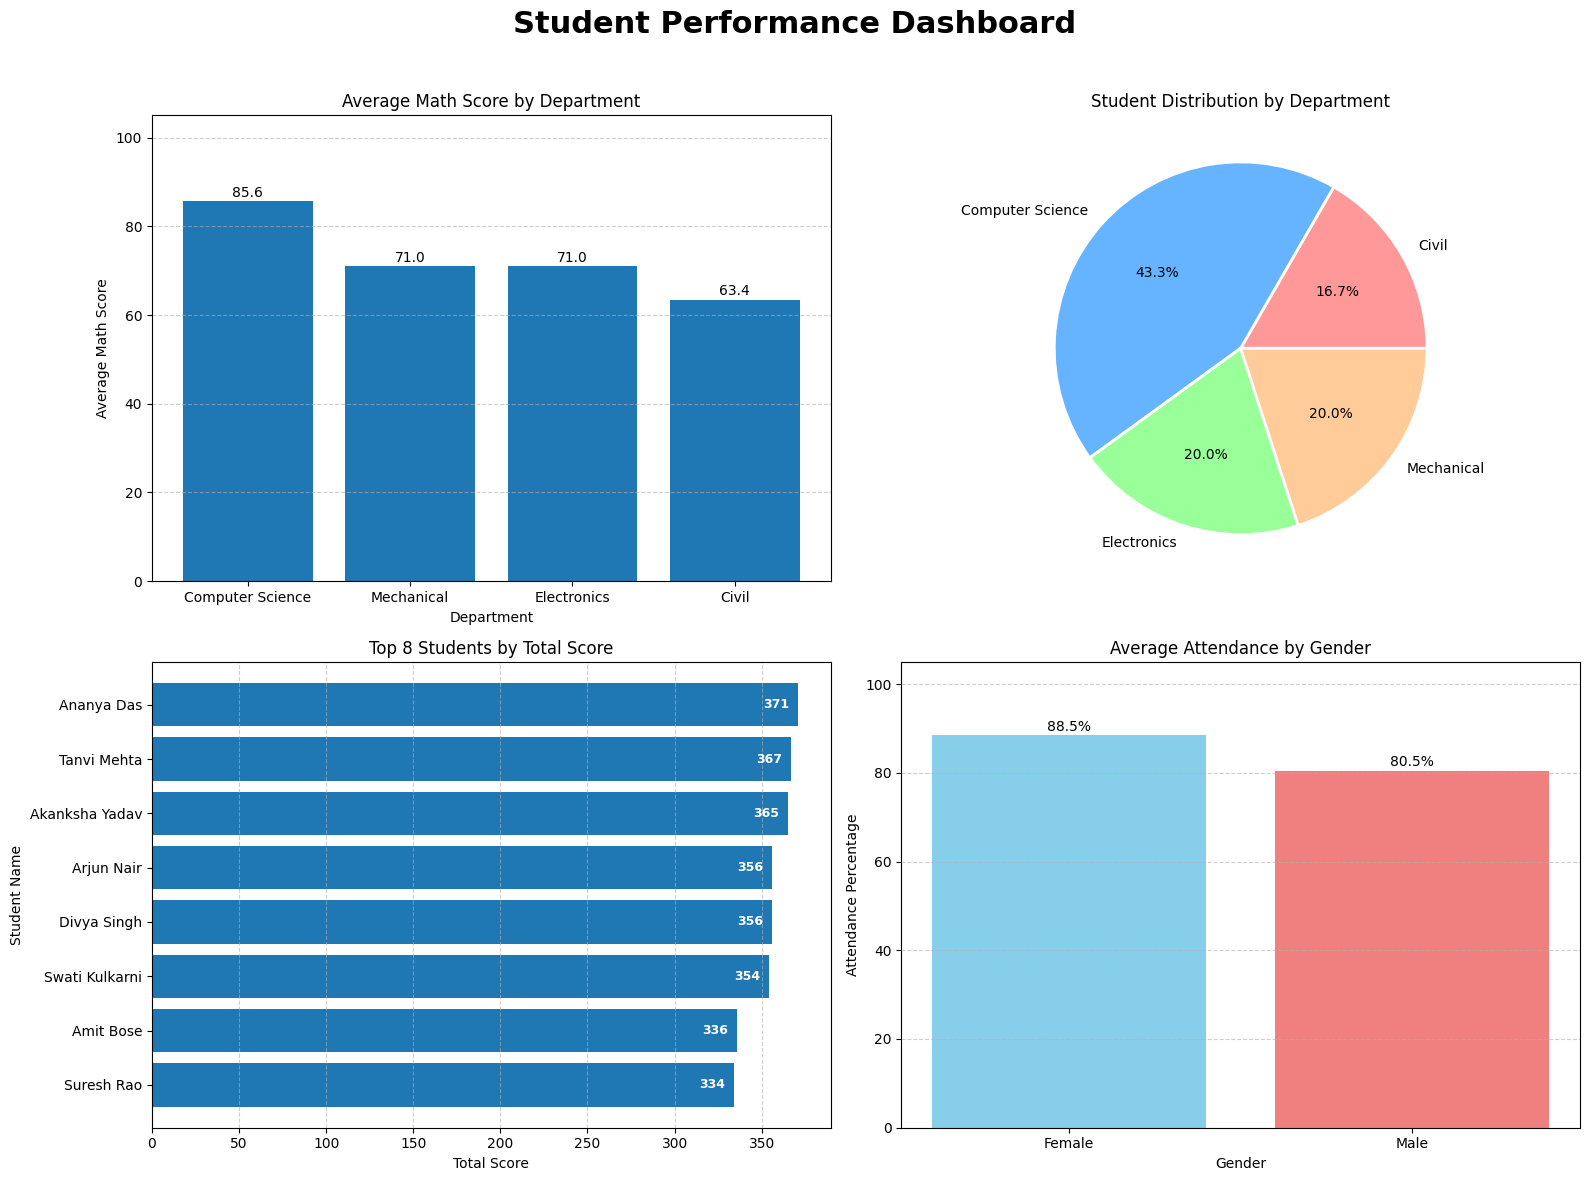


Dashboard saved successfully as 'student_dashboard.png'


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Dashboard Main Title
fig.suptitle(
    "Student Performance Dashboard",
    fontsize=22,
    fontweight='bold'
)

ax1 = axes[0, 0]

bars1 = ax1.bar(
    avg_math_df["department"],
    avg_math_df["avg_math_score"]
)

ax1.set_title("Average Math Score by Department")
ax1.set_xlabel("Department")
ax1.set_ylabel("Average Math Score")
ax1.set_ylim(0, 105)

ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Value Labels
for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height}",
        ha='center',
        fontsize=10
    )
ax2 = axes[0, 1]

colors = [
    '#ff9999',
    '#66b3ff',
    '#99ff99',
    '#ffcc99',
    '#c2c2f0'
]

ax2.pie(
    student_count_df["student_count"],
    labels=student_count_df["department"],
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

ax2.set_title("Student Distribution by Department")

ax3 = axes[1, 0]

# Reverse for highest scorer on top
top_students_plot = top_students_df.iloc[::-1]

bars3 = ax3.barh(
    top_students_plot["name"],
    top_students_plot["total_score"]
)

ax3.set_title("Top 8 Students by Total Score")
ax3.set_xlabel("Total Score")
ax3.set_ylabel("Student Name")

ax3.grid(axis='x', linestyle='--', alpha=0.6)

# Score Labels Inside Bars
for bar in bars3:
    width = bar.get_width()
    ax3.text(
        width - 20,
        bar.get_y() + bar.get_height()/2,
        f"{width}",
        va='center',
        color='white',
        fontsize=9,
        fontweight='bold'
    )

ax4 = axes[1, 1]

bars4 = ax4.bar(
    attendance_df["gender"],
    attendance_df["avg_attendance"],
    color=['skyblue', 'lightcoral']
)

ax4.set_title("Average Attendance by Gender")
ax4.set_xlabel("Gender")
ax4.set_ylabel("Attendance Percentage")
ax4.set_ylim(0, 105)

ax4.grid(axis='y', linestyle='--', alpha=0.6)

# Percentage Labels
for bar in bars4:
    height = bar.get_height()
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height}%",
        ha='center',
        fontsize=10
    )


plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "student_dashboard.png",
    dpi=150,
    bbox_inches='tight'
)

# Show Dashboard
plt.show()

conn.close()

print("\nDashboard saved successfully as 'student_dashboard.png'")